# 07 — Return Method Analysis (Block F)
## REVER Logistics Cost & Revenue Analysis — 2025

Answers Block F questions: margin by return method, crossed with carrier and merchant.

**Requires:** `01_preparacion.ipynb` to have been run first.

In [1]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
warnings.filterwarnings("ignore")

PROCESSED = Path("../processed")
PALETTE = {
    "primary": "#2C5F8A", "positive": "#2A9D8F", "negative": "#E63946",
    "neutral": "#ADB5BD", "accent": "#F4A261", "bg": "#FFFFFF", "grid": "#F0F0F0",
}
CARRIER_COLORS = {
    "Correos": "#F4A261", "Correos Express": "#E63946",
    "UPS": "#8B5E3C", "GLS": "#2A9D8F", "BRT": "#457B9D",
}
plt.rcParams.update({
    "figure.facecolor": PALETTE["bg"], "axes.facecolor": PALETTE["bg"],
    "axes.grid": True, "grid.color": PALETTE["grid"], "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": True, "axes.spines.bottom": True,
    "axes.edgecolor": "#CCCCCC", "font.family": "sans-serif", "font.size": 11,
    "axes.titlesize": 14, "axes.titleweight": "bold", "axes.labelsize": 11,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "legend.frameon": False, "legend.fontsize": 10,
    "figure.dpi": 110, "figure.figsize": (14, 5),
})
FIG_W, FIG_H = 14, 5

rever   = pd.read_parquet(PROCESSED / "rever.parquet")
merged  = pd.read_parquet(PROCESSED / "merged.parquet")
matched = merged.dropna(subset=["rever_revenue_net"]).copy()

# Join return_method from rever (not in merged by default)
if "return_method" in rever.columns:
    rm_map = rever.set_index("tracking_id")["return_method"].to_dict()
    matched["return_method"] = matched["tracking_id"].map(rm_map)

print(f"matched: {len(matched):,} rows")
if "return_method" in matched.columns:
    print(f"return_method values: {matched['return_method'].value_counts().to_dict()}")
else:
    print("return_method column not available in REVER dataset")

matched: 244,149 rows
return_method values: {'DROP_OFF_POINT': 186556, 'HOME_PICK_UP': 56275, 'DELIVERY_PICKUP': 1318}


---
## F1 — Margin by return method

HOME_PICK_UP requires active carrier pickup (more expensive).
DROP_OFF_POINT is cheaper (customer brings parcel to a shop).
If REVER doesn't price each method correctly, some methods are structural loss-makers.

  return_method  shipments  total_margin  avg_margin_eur  avg_cost  avg_revenue
 DROP_OFF_POINT     186556   368549.9372        1.975546  6.333300     8.308846
   HOME_PICK_UP      56275    76035.3286        1.351139  7.633029     8.984168
DELIVERY_PICKUP       1318     -833.9700       -0.632754  7.307443     6.674689


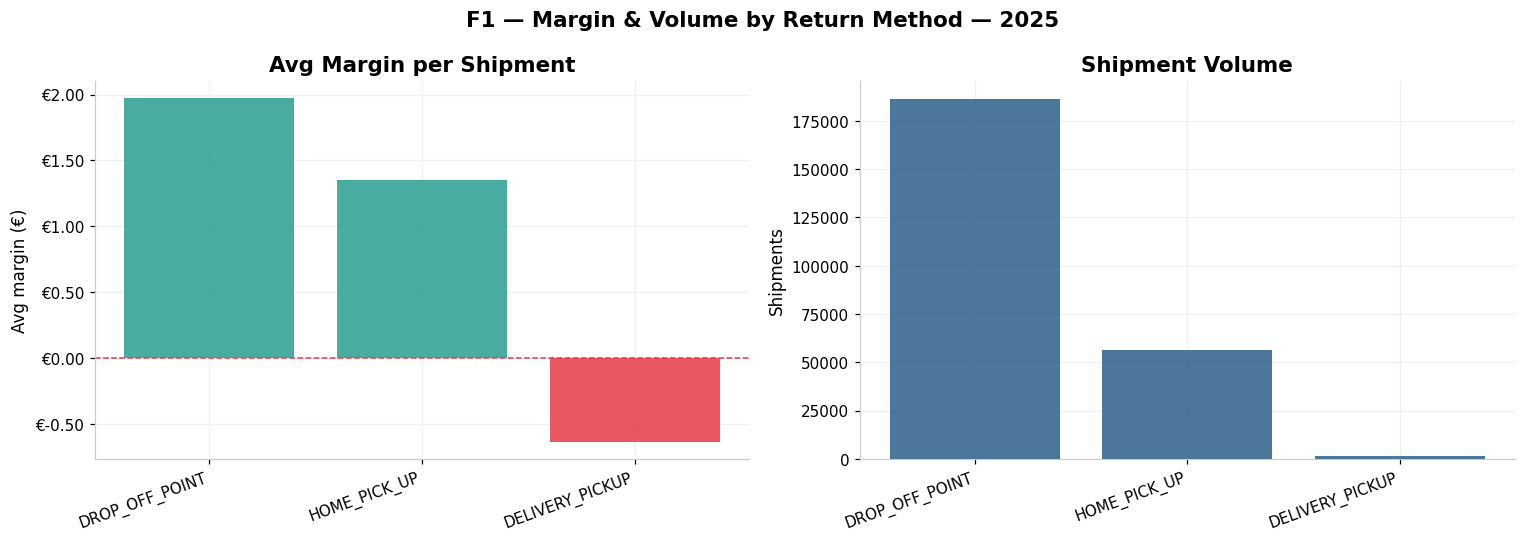

In [2]:
# ── F1: Margin by return method ───────────────────────────────────────────────
if "return_method" not in matched.columns or matched["return_method"].isna().all():
    print("return_method not available — skipping F1. Check REVER dataset columns.")
else:
    rm = (
        matched.groupby("return_method")
        .agg(
            shipments      = ("tracking_id",       "count"),
            total_margin   = ("margin_eur",        "sum"),
            avg_margin_eur = ("margin_eur",        "mean"),
            avg_cost       = ("carrier_cost_net",  "mean"),
            avg_revenue    = ("rever_revenue_net", "mean"),
        )
        .reset_index()
        .sort_values("avg_margin_eur", ascending=False)
    )
    print(rm.to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(FIG_W, FIG_H))
    colors_rm = [PALETTE["positive"] if m > 0 else PALETTE["negative"] for m in rm["avg_margin_eur"]]

    axes[0].bar(rm["return_method"], rm["avg_margin_eur"], color=colors_rm, alpha=0.85, zorder=3)
    axes[0].axhline(0, color=PALETTE["negative"], linewidth=1, linestyle="--")
    axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"€{v:.2f}"))
    axes[0].set_title("Avg Margin per Shipment")
    axes[0].set_ylabel("Avg margin (€)")
    axes[0].set_xticklabels(rm["return_method"], rotation=20, ha="right")

    axes[1].bar(rm["return_method"], rm["shipments"], color=PALETTE["primary"], alpha=0.85, zorder=3)
    axes[1].set_title("Shipment Volume")
    axes[1].set_ylabel("Shipments")
    axes[1].set_xticklabels(rm["return_method"], rotation=20, ha="right")

    fig.suptitle("F1 — Margin & Volume by Return Method — 2025", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

---
## F1 (why) — Margin by return method × carrier

Does margin differ by carrier for the same return method?
HOME_PICK_UP with carrier A might be profitable, with carrier B not.

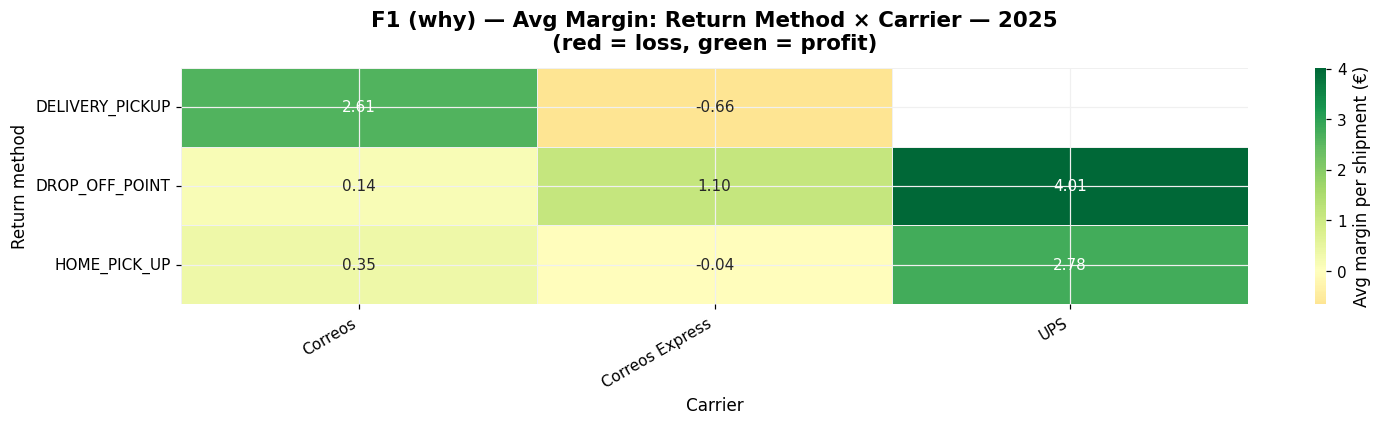

In [3]:
# ── F1 (why): Margin by return method × carrier ───────────────────────────────
if "return_method" not in matched.columns or matched["return_method"].isna().all():
    print("return_method not available — skipping.")
else:
    rm_carrier = (
        matched.groupby(["return_method", "carrier"])["margin_eur"]
        .mean()
        .reset_index()
        .pivot(index="return_method", columns="carrier", values="margin_eur")
    )

    fig, ax = plt.subplots(figsize=(FIG_W, max(4, len(rm_carrier) * 1.2)))
    sns.heatmap(
        rm_carrier, ax=ax, cmap="RdYlGn", center=0,
        annot=True, fmt=".2f", annot_kws={"size": 10},
        linewidths=0.4, linecolor=PALETTE["grid"],
        cbar_kws={"label": "Avg margin per shipment (€)"},
    )
    ax.set_xlabel("Carrier")
    ax.set_ylabel("Return method")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
    ax.set_title("F1 (why) — Avg Margin: Return Method × Carrier — 2025\n(red = loss, green = profit)", pad=12)
    plt.tight_layout()
    plt.show()

---
## F1 (why) — Margin by return method × merchant (top 20)

Does any merchant have a specific return method that systematically destroys margin?
Heatmap: rows = top 20 merchants, columns = return methods, value = avg margin.

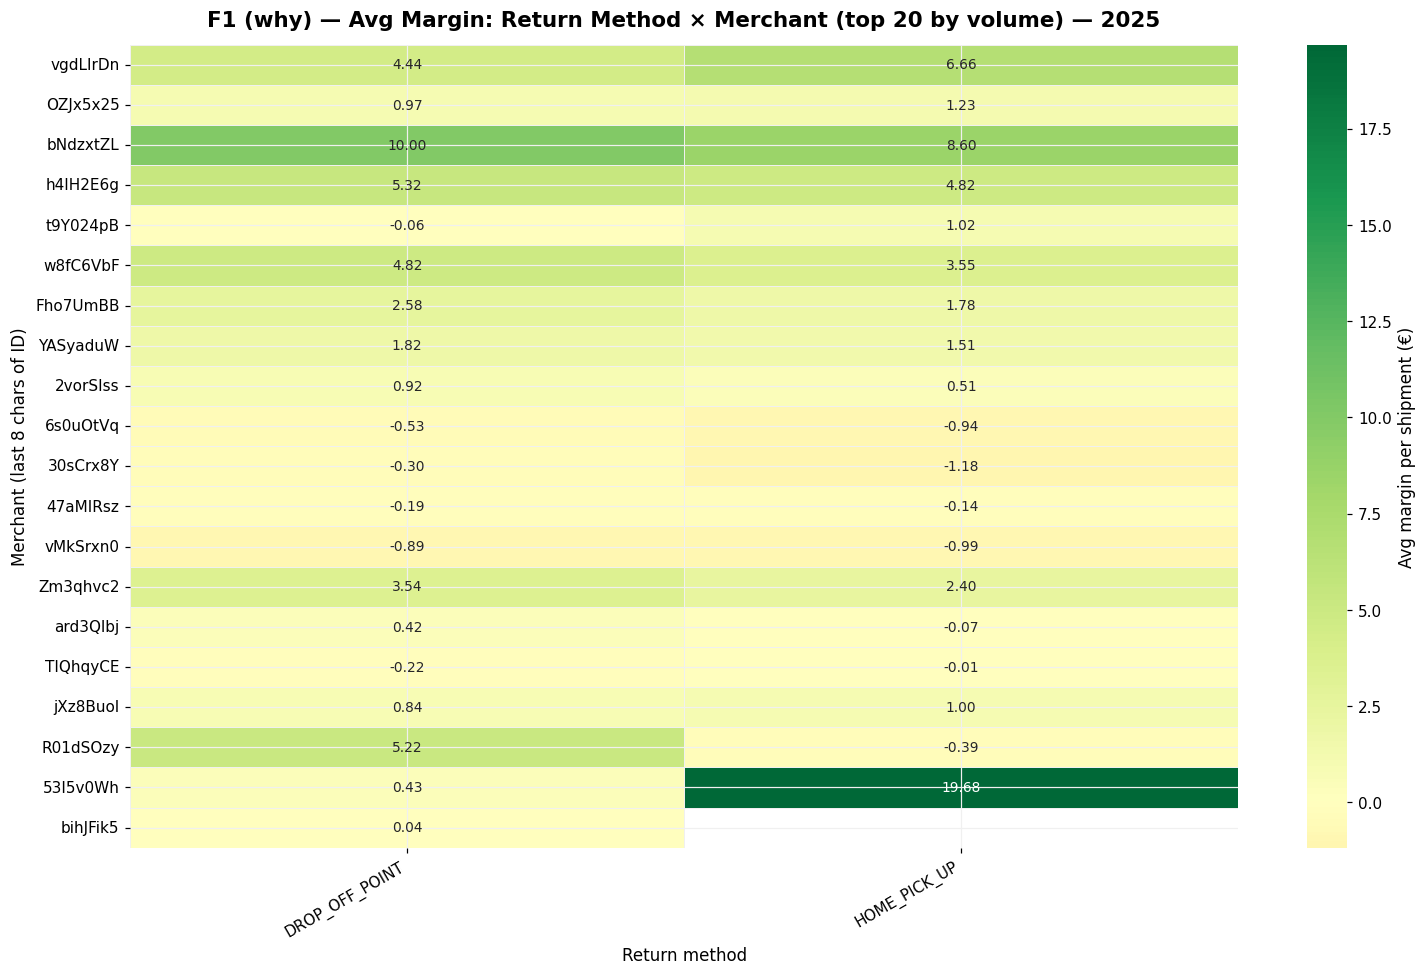

In [4]:
# ── F1 (why): Margin by return method × merchant (top 20) ────────────────────
if "return_method" not in matched.columns or matched["return_method"].isna().all():
    print("return_method not available — skipping.")
else:
    top20_m = (
        matched.groupby("stripe_cust_id")["tracking_id"].count()
        .sort_values(ascending=False).head(20).index
    )
    rm_merchant = (
        matched[matched["stripe_cust_id"].isin(top20_m)]
        .groupby(["stripe_cust_id", "return_method"])["margin_eur"]
        .mean()
        .reset_index()
        .pivot(index="stripe_cust_id", columns="return_method", values="margin_eur")
    )
    rm_merchant.index = rm_merchant.index.str[-8:]

    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H + 4))
    sns.heatmap(
        rm_merchant, ax=ax, cmap="RdYlGn", center=0,
        annot=True, fmt=".2f", annot_kws={"size": 9},
        linewidths=0.4, linecolor=PALETTE["grid"],
        cbar_kws={"label": "Avg margin per shipment (€)"},
    )
    ax.set_xlabel("Return method")
    ax.set_ylabel("Merchant (last 8 chars of ID)")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
    ax.set_title("F1 (why) — Avg Margin: Return Method × Merchant (top 20 by volume) — 2025", pad=12)
    plt.tight_layout()
    plt.show()